In [2]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

In [22]:
xls = pd.ExcelFile('data\\ExpoM\\13.03.2024\\Static_16Hz_10uT_X.xlsx')
df = pd.read_excel(xls, 'TIME DOMAIN')

deltatime = 1 / 1024
n_samples = 1024

acc = np.array(df.iloc[::4, [8, 9, 10]])
gyro = np.deg2rad(np.array(df.iloc[::4, [5, 6, 7]]))
mag = np.array(df.iloc[:, [1, 2, 3]])

In [23]:
w = 1024
gyro_filtered = np.array([np.mean(gyro[max(0, i-w//2):min(len(gyro)-1, i+w//2)], axis=0) for i in range(len(gyro))])
acc_filtered = np.array([np.mean(acc[max(0, i-w//2):min(len(acc)-1, i+w//2)], axis=0) for i in range(len(acc))])

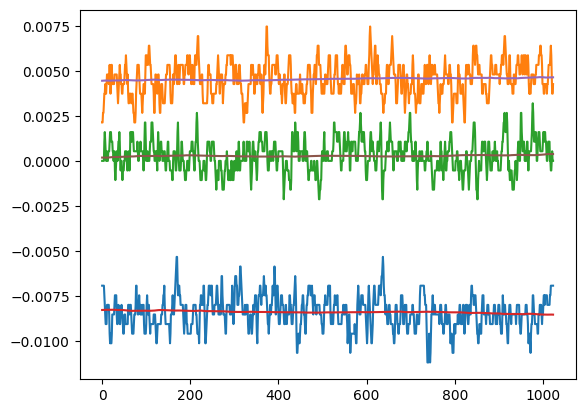

In [24]:
plt.plot(gyro)
plt.plot(gyro_filtered)

[ 0.03011135 -0.20218271  9.98891062]


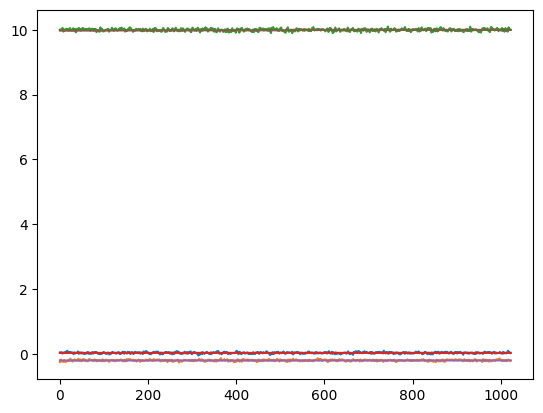

In [25]:
plt.plot(acc[1:])
plt.plot(acc_filtered)

print(np.mean(acc_filtered, axis=0))

In [26]:
deviation_list = []
for i in range(len(gyro)):
    deviation_list.append(np.square(gyro[i] - gyro_filtered[i]))

np.sqrt(np.mean(deviation_list, axis=0))

array([0.00090463, 0.00091974, 0.00087195])

In [27]:
deviation_list = []
for i in range(1, len(acc[1:])):
    deviation_list.append(np.square(acc[i] - acc_filtered[i]))

np.sqrt(np.mean(deviation_list, axis=0))

array([0.02215415, 0.02024886, 0.03660316])